# IKEA Supply Chain Analytics

## Goal / 目标
This upgraded notebook further improves the forecasting module and adds a geographic map dashboard for the IKEA network in the dataset.

本版本进一步优化预测模块，并加入基于地理位置的 IKEA 网络地图可视化。


> **Important note / 重要说明**  
> The store names visible in this dataset mainly span **Southern Europe and Morocco / Mediterranean region**.  
> 该数据集当前可见的门店主要分布在**南欧与摩洛哥等地中海区域**，并**未明确出现海湾/中东核心城市门店名称**。  
> Therefore, in your final report, it is safer to describe this dataset as an **IKEA Europe–MENA / Mediterranean regional sample** rather than a fully representative Middle East–Europe network.


In [70]:
# =========================
# 0. Setup / 环境准备
# =========================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from scipy.optimize import linprog
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from statsmodels.tsa.arima.model import ARIMA
import plotly.express as px

plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.unicode_minus'] = False


# 1. Problem Definition / 问题定义

## Research Question / 研究问题
How can IKEA improve category-level demand forecasting and convert forecasts into actionable inventory allocation decisions across its regional store network?

IKEA 如何提升品类层级的需求预测能力，并将预测结果转化为可执行的区域库存配置决策？

本版本通过以下方式提升可预测性：
1. 将需求聚合到**品类-周**层级  
2. 构造更丰富的**日历、滞后、滚动统计特征**  
3. 采用更强的**XGBoost 非线性模型**  
4. 将需求预测转化为**受容量约束的优化决策**

In [3]:
# =========================
# 2. Data Loading / 数据读取
# =========================
file_path = 'Ikea_Dataset.csv'
df = pd.read_csv(file_path)

print('Shape / 数据维度:', df.shape)
display(df.head())

df['Date'] = pd.to_datetime(df['Date'])
df['promotion'] = df['promotion'].astype(int)
df['is_assembly_required'] = df['is_assembly_required'].astype(int)
df['is_seasonal_item'] = df['is_seasonal_item'].astype(int)

print('Date range / 日期范围:', df['Date'].min().date(), 'to', df['Date'].max().date())
print('Stores / 门店数量:', df['store'].nunique())
print('Categories / 品类数量:', df['category'].nunique())

Shape / 数据维度: (1001, 14)


,Date,sku,product_name,category,units_sold,price,promotion,store,stock_level,is_assembly_required,customer_rating,fulfillment_center_id,profit_margin_percent,is_seasonal_item
0,2024-07-28,RASKOG-013,Råskog Cart,Storage,46.42,49.00,0,Athens,202,False,3.99,ATH_FC,34.36,False
1,2024-10-09,FJADRAR-014,Fjädrar Cushion,Decoration,46.50,17.32,1,Milan,29,False,4.61,MIL_FC,8.99,False
2,2024-10-26,RASKOG-013,Råskog Cart,Storage,20.28,49.00,0,Naples,484,False,4.42,NAP_FC,34.36,True
3,2024-09-22,FRIHET-010,Friheten Sofa Bed,Living Room,28.11,610.36,0,Thessaloniki,198,True,3.84,THS_FC,32.51,False
4,2024-09-08,ALEX-012,Alex Drawer Unit,Office,8.96,93.31,0,Naples,594,True,4.91,NAP_FC,33.03,False


Date range / 日期范围: 2024-01-02 to 2025-05-31
Stores / 门店数量: 12
Categories / 品类数量: 7


# 3. Data Understanding & Map Dashboard / 数据理解与地图仪表板

In [4]:
store_summary = (
    df.groupby('store', as_index=False)
      .agg(total_units_sold=('units_sold', 'sum'),
           avg_stock_level=('stock_level', 'mean'),
           avg_customer_rating=('customer_rating', 'mean'),
           avg_price=('price', 'mean'),
           records=('sku', 'count'))
      .sort_values('total_units_sold', ascending=False)
)
display(store_summary)

,store,total_units_sold,avg_stock_level,avg_customer_rating,avg_price,records
10,Valencia,2923.10,448.444444,4.382121,156.606970,99
8,Rome,2855.86,441.367925,4.439340,159.257075,106
7,Porto,2792.77,435.380952,4.420476,204.089333,105
4,Marseille,2738.88,390.313131,4.391818,113.788889,99
9,Thessaloniki,2699.13,419.088235,4.431275,146.627843,102
6,Naples,2562.31,433.520408,4.398673,150.762959,98
1,Barcelona,2480.01,411.290000,4.420500,143.904000,100
5,Milan,2450.92,421.125000,4.402841,142.559318,88
0,Athens,2344.37,375.325301,4.420000,178.467470,83
2,Bordeaux,2086.59,413.637500,4.441125,187.349875,80


In [5]:
store_coords = pd.DataFrame({
    'store': ['Athens', 'Milan', 'Naples', 'Thessaloniki', 'Barcelona', 'Porto',
              'Valencia', 'Rome', 'Marseille', 'Bordeaux', 'Zenata', 'Marrakech'],
    'latitude': [37.9838, 45.4642, 40.8518, 40.6401, 41.3874, 41.1579,
                 39.4699, 41.9028, 43.2965, 44.8378, 33.7870, 31.6295],
    'longitude': [23.7275, 9.1900, 14.2681, 22.9444, 2.1686, -8.6291,
                  -0.3763, 12.4964, 5.3698, -0.5792, -7.1597, -7.9811],
    'country_region': ['Greece', 'Italy', 'Italy', 'Greece', 'Spain', 'Portugal',
                       'Spain', 'Italy', 'France', 'France', 'Morocco', 'Morocco']
})
store_map = store_summary.merge(store_coords, on='store', how='left')
display(store_map)

,store,total_units_sold,avg_stock_level,avg_customer_rating,avg_price,records,latitude,longitude,country_region
0,Valencia,2923.10,448.444444,4.382121,156.606970,99,39.4699,-0.3763,Spain
1,Rome,2855.86,441.367925,4.439340,159.257075,106,41.9028,12.4964,Italy
2,Porto,2792.77,435.380952,4.420476,204.089333,105,41.1579,-8.6291,Portugal
3,Marseille,2738.88,390.313131,4.391818,113.788889,99,43.2965,5.3698,France
4,Thessaloniki,2699.13,419.088235,4.431275,146.627843,102,40.6401,22.9444,Greece
5,Naples,2562.31,433.520408,4.398673,150.762959,98,40.8518,14.2681,Italy
6,Barcelona,2480.01,411.290000,4.420500,143.904000,100,41.3874,2.1686,Spain
7,Milan,2450.92,421.125000,4.402841,142.559318,88,45.4642,9.1900,Italy
8,Athens,2344.37,375.325301,4.420000,178.467470,83,37.9838,23.7275,Greece
9,Bordeaux,2086.59,413.637500,4.441125,187.349875,80,44.8378,-0.5792,France


In [80]:
import plotly.graph_objects as go
import plotly.io as pio

plot_df = store_map.copy()
plot_df['units_share_pct'] = (plot_df['total_units_sold'] / plot_df['total_units_sold'].sum() * 100).round(2)

# 用总销量决定颜色和大小，让主力门店更显眼
size_min, size_max = 14, 48
min_val = plot_df['total_units_sold'].min()
max_val = plot_df['total_units_sold'].max()
plot_df['bubble_size'] = size_min + (plot_df['total_units_sold'] - min_val) / (max_val - min_val + 1e-9) * (size_max - size_min)

fig = go.Figure()

# 1) 主地图散点层：门店规模 + 评分信息
fig.add_trace(go.Scattergeo(
    lon=plot_df['longitude'],
    lat=plot_df['latitude'],
    text=plot_df['store'],
    mode='markers+text',
    textposition='top center',
    marker=dict(
        size=plot_df['bubble_size'],
        color=plot_df['total_units_sold'],
        colorscale='YlGnBu',
        cmin=float(plot_df['total_units_sold'].min()),
        cmax=float(plot_df['total_units_sold'].max()),
        opacity=0.88,
        line=dict(width=1.2, color='white'),
        colorbar=dict(title='Total Units Sold')
    ),
    customdata=np.stack([
        plot_df['country_region'],
        plot_df['avg_stock_level'],
        plot_df['avg_customer_rating'],
        plot_df['records'],
        plot_df['units_share_pct']
    ], axis=-1),
    hovertemplate=(
        '<b>%{text}</b><br>'
        'Region: %{customdata[0]}<br>'
        'Total Units Sold: %{marker.color:.0f}<br>'
        'Sales Share: %{customdata[4]:.2f}%<br>'
        'Avg Stock Level: %{customdata[1]:.1f}<br>'
        'Avg Customer Rating: %{customdata[2]:.2f}<br>'
        'Records: %{customdata[3]:.0f}<extra></extra>'
    ),
    name='Store Nodes'
))

# 2) 运营走廊：区域内的关键连接线，增强网络感
corridors = [
    ('Porto', 'Barcelona'),
    ('Barcelona', 'Marseille'),
    ('Marseille', 'Milan'),
    ('Milan', 'Rome'),
    ('Rome', 'Athens'),
    ('Athens', 'Thessaloniki'),
    ('Naples', 'Rome'),
    ('Valencia', 'Barcelona'),
    ('Bordeaux', 'Marseille'),
    ('Zenata', 'Marrakech')
]
coord_lookup = plot_df.set_index('store')[['longitude', 'latitude']]

for src, dst in corridors:
    if src in coord_lookup.index and dst in coord_lookup.index:
        fig.add_trace(go.Scattergeo(
            lon=[coord_lookup.loc[src, 'longitude'], coord_lookup.loc[dst, 'longitude']],
            lat=[coord_lookup.loc[src, 'latitude'], coord_lookup.loc[dst, 'latitude']],
            mode='lines',
            line=dict(width=1.8, color='rgba(19, 82, 138, 0.45)'),
            hoverinfo='skip',
            showlegend=False
        ))

# 3) 以销量最高门店作为枢纽，增加辐射线
hub = plot_df.sort_values('total_units_sold', ascending=False).iloc[0]
others = plot_df[plot_df['store'] != hub['store']]
for _, row in others.iterrows():
    fig.add_trace(go.Scattergeo(
        lon=[hub['longitude'], row['longitude']],
        lat=[hub['latitude'], row['latitude']],
        mode='lines',
        line=dict(width=0.8, color='rgba(240, 124, 21, 0.28)', dash='dot'),
        hoverinfo='skip',
        showlegend=False
    ))

fig.update_geos(
    scope='europe',
    projection_type='natural earth',
    showcountries=True,
    countrycolor='rgba(90, 90, 90, 0.35)',
    showland=True,
    landcolor='rgb(245, 247, 250)',
    showocean=True,
    oceancolor='rgb(228, 236, 245)',
    showlakes=True,
    lakecolor='rgb(228, 236, 245)',
    lataxis_range=[25, 52],
    lonaxis_range=[-13, 31]
)

fig.update_layout(
    title='IKEA Regional Supply Network',
    template='plotly_white',
    width=1700,
    height=760,
    margin=dict(l=10, r=10, t=70, b=10),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=0.01,
        xanchor='left',
        x=0.01,
        bgcolor='rgba(255,255,255,0.75)'
    ),
    annotations=[
        dict(
            x=0.01,
            y=1.03,
            xref='paper',
            yref='paper',
            showarrow=False,
            align='left',
            text=(
                f"Hub Store: <b>{hub['store']}</b> | "
                f"Top Sales: <b>{hub['total_units_sold']:.0f}</b>"
            )
        )
    ]
)

fig.show(config={'responsive': True, 'displayModeBar': True})

# 导出交互地图为全屏 HTML（覆盖浏览器视窗）
map_html_path = '/Users/huanghaojie/Downloads/IKEA_Regional_Supply_Network_Map_Interactive_Fullscreen.html'
plot_html = pio.to_html(
    fig,
    include_plotlyjs='cdn',
    full_html=False,
    config={'responsive': True, 'displayModeBar': True}
)

fullscreen_html = f"""<!DOCTYPE html>
<html lang=\"en\">
<head>
  <meta charset=\"UTF-8\" />
  <meta name=\"viewport\" content=\"width=device-width, initial-scale=1.0\" />
  <title>IKEA Regional Supply Network Map</title>
  <style>
    html, body {{
      width: 100%;
      height: 100%;
      margin: 0;
      padding: 0;
      overflow: hidden;
      background: #f3f5f8;
      font-family: Arial, sans-serif;
    }}
    #map-wrap {{
      position: fixed;
      inset: 0;
      width: 100vw;
      height: 100vh;
    }}
    #map-wrap .plotly-graph-div {{
      width: 100% !important;
      height: 100% !important;
    }}
  </style>
</head>
<body>
  <div id=\"map-wrap\">{plot_html}</div>
</body>
</html>
"""

with open(map_html_path, 'w', encoding='utf-8') as f:
    f.write(fullscreen_html)

print('Fullscreen interactive map exported to / 全屏交互地图已导出到:', map_html_path)

Fullscreen interactive map exported to / 全屏交互地图已导出到: /Users/huanghaojie/Downloads/IKEA_Regional_Supply_Network_Map_Interactive_Fullscreen.html


In [31]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# =========================
# Supply Chain Dashboard (Compact Multi-View)
# =========================

dashboard_df = df.copy()
dashboard_df['week_start'] = dashboard_df['Date'] - pd.to_timedelta(dashboard_df['Date'].dt.dayofweek, unit='D')
dashboard_df['month'] = dashboard_df['Date'].dt.to_period('M').dt.to_timestamp()

# Core aggregations
category_stats = (
    dashboard_df.groupby('category', as_index=False)
    .agg(
        units_sold=('units_sold', 'sum'),
        avg_margin=('profit_margin_percent', 'mean'),
        avg_rating=('customer_rating', 'mean'),
        avg_stock=('stock_level', 'mean'),
        promo_rate=('promotion', 'mean')
    )
    .sort_values('units_sold', ascending=False)
)

store_stats = (
    dashboard_df.groupby('store', as_index=False)
    .agg(
        units_sold=('units_sold', 'sum'),
        avg_stock=('stock_level', 'mean'),
        avg_rating=('customer_rating', 'mean'),
        avg_price=('price', 'mean')
    )
    .sort_values('units_sold', ascending=False)
)

weekly = (
    dashboard_df.groupby('week_start', as_index=False)
    .agg(units_sold=('units_sold', 'sum'))
    .sort_values('week_start')
)
weekly['ma4'] = weekly['units_sold'].rolling(4, min_periods=1).mean()

monthly_promo = (
    dashboard_df.groupby(['month', 'promotion'], as_index=False)['units_sold']
    .sum()
)

# Treemap hierarchy data (robust ids/parents to guarantee rendering)
treemap_leaf = (
    dashboard_df.groupby(['store', 'category'], as_index=False)['units_sold']
    .sum()
)
treemap_store = treemap_leaf.groupby('store', as_index=False)['units_sold'].sum()

parent_ids = ['store:' + s for s in treemap_store['store']]
parent_labels = treemap_store['store'].tolist()
parent_parents = [''] * len(treemap_store)
parent_values = treemap_store['units_sold'].tolist()

child_ids = ['store:' + s + '|cat:' + c for s, c in zip(treemap_leaf['store'], treemap_leaf['category'])]
child_labels = treemap_leaf['category'].tolist()
child_parents = ['store:' + s for s in treemap_leaf['store']]
child_values = treemap_leaf['units_sold'].tolist()

tree_ids = parent_ids + child_ids
tree_labels = parent_labels + child_labels
tree_parents = parent_parents + child_parents
tree_values = parent_values + child_values

# KPI values for summary table
kpi_total_units = float(dashboard_df['units_sold'].sum())
kpi_total_revenue = float((dashboard_df['units_sold'] * dashboard_df['price']).sum())
kpi_avg_rating = float(dashboard_df['customer_rating'].mean())
kpi_avg_stock = float(dashboard_df['stock_level'].mean())
kpi_cv = float(dashboard_df['units_sold'].std() / (dashboard_df['units_sold'].mean() + 1e-9))

promo_avg = dashboard_df.groupby('promotion')['units_sold'].mean()
if 0 in promo_avg.index and 1 in promo_avg.index and promo_avg.loc[0] > 0:
    kpi_promo_uplift = float((promo_avg.loc[1] - promo_avg.loc[0]) / promo_avg.loc[0] * 100)
else:
    kpi_promo_uplift = np.nan

# Pie data (Top 6 + Others)
pie_df = category_stats.copy()
if len(pie_df) > 6:
    top6 = pie_df.head(6).copy()
    others = pd.DataFrame({'category': ['Others'], 'units_sold': [pie_df['units_sold'].iloc[6:].sum()]})
    pie_df = pd.concat([top6[['category', 'units_sold']], others], ignore_index=True)
else:
    pie_df = pie_df[['category', 'units_sold']]

# Radar data (Top 3 categories)
radar_top = category_stats.head(3).copy()
radar_top['stock_eff'] = radar_top['units_sold'] / (radar_top['avg_stock'] + 1e-9)
radar_metrics = ['units_sold', 'avg_margin', 'avg_rating', 'stock_eff', 'promo_rate']
radar_labels = ['Demand', 'Margin', 'Rating', 'Stock Efficiency', 'Promo Intensity']

for m in radar_metrics:
    m_min = radar_top[m].min()
    m_max = radar_top[m].max()
    radar_top[m + '_norm'] = 100 * (radar_top[m] - m_min) / (m_max - m_min + 1e-9)

# Correlation heatmap columns
corr_cols = ['units_sold', 'price', 'stock_level', 'customer_rating', 'profit_margin_percent', 'promotion']
corr = dashboard_df[corr_cols].corr(numeric_only=True)

# Layout: compact, dense, and no wasted top space
fig = make_subplots(
    rows=3,
    cols=4,
    specs=[
        [{'type': 'domain'}, {'type': 'xy'}, {'type': 'xy'}, {'type': 'polar'}],
        [{'type': 'xy'}, {'type': 'xy'}, {'type': 'xy'}, {'type': 'heatmap'}],
        [{'type': 'xy'}, {'type': 'domain'}, {'type': 'table', 'colspan': 2}, None]
    ],
    subplot_titles=(
        'Category Demand Share',
        'Top 10 Stores by Units Sold',
        'Weekly Demand Trend + MA(4)',
        'Category Performance Radar (Top 3)',
        'Demand Distribution: Promo vs No Promo',
        'Demand Spread by Category (Top 8)',
        'Store Efficiency Scatter',
        'Metric Correlation Heatmap',
        'Monthly Demand by Promotion',
        'Store-Category Contribution',
        'Executive KPI Summary'
    ),
    vertical_spacing=0.09,
    horizontal_spacing=0.08,
    row_heights=[0.33, 0.33, 0.34]
)

# 1) Pie chart
fig.add_trace(go.Pie(
    labels=pie_df['category'],
    values=pie_df['units_sold'],
    hole=0.42,
    textinfo='percent+label',
    hovertemplate='Category: %{label}<br>Units Sold: %{value:,.0f}<extra></extra>',
    showlegend=False
), row=1, col=1)

# 2) Bar chart (Top stores)
top_store = store_stats.head(10)
fig.add_trace(go.Bar(
    x=top_store['store'],
    y=top_store['units_sold'],
    marker=dict(color='#1f4e79'),
    name='Store Units',
    hovertemplate='Store: %{x}<br>Units Sold: %{y:,.0f}<extra></extra>'
), row=1, col=2)

# 3) Line chart (weekly + MA)
fig.add_trace(go.Scatter(
    x=weekly['week_start'],
    y=weekly['units_sold'],
    mode='lines+markers',
    line=dict(color='#1f4e79', width=2),
    marker=dict(size=4),
    name='Weekly Units',
    hovertemplate='Week: %{x|%Y-%m-%d}<br>Units: %{y:,.0f}<extra></extra>'
), row=1, col=3)

fig.add_trace(go.Scatter(
    x=weekly['week_start'],
    y=weekly['ma4'],
    mode='lines',
    line=dict(color='#d97706', width=3, dash='dash'),
    name='MA(4)',
    hovertemplate='Week: %{x|%Y-%m-%d}<br>MA(4): %{y:,.0f}<extra></extra>'
), row=1, col=3)

# 4) Radar chart
for _, r in radar_top.iterrows():
    r_values = [r[m + '_norm'] for m in radar_metrics]
    r_values += [r_values[0]]
    theta_vals = radar_labels + [radar_labels[0]]
    fig.add_trace(go.Scatterpolar(
        r=r_values,
        theta=theta_vals,
        fill='toself',
        name='Radar-' + str(r['category']),
        opacity=0.35,
        showlegend=False
    ), row=1, col=4)

# 5) Histogram (promo vs non-promo)
for promo_flag, color in [(0, '#9ca3af'), (1, '#ef4444')]:
    subset = dashboard_df.loc[dashboard_df['promotion'] == promo_flag, 'units_sold']
    fig.add_trace(go.Histogram(
        x=subset,
        nbinsx=24,
        opacity=0.68,
        marker=dict(color=color),
        name='Promo Dist' if promo_flag == 1 else 'No Promo Dist',
        hovertemplate='Units Sold: %{x}<br>Count: %{y}<extra></extra>'
    ), row=2, col=1)

# 6) Box plot (Top 8 categories)
for cat in category_stats.head(8)['category']:
    vals = dashboard_df.loc[dashboard_df['category'] == cat, 'units_sold']
    fig.add_trace(go.Box(
        y=vals,
        x=[cat] * len(vals),
        boxmean='sd',
        name='Box-' + str(cat),
        showlegend=False,
        hovertemplate='Category: ' + str(cat) + '<br>Units: %{y}<extra></extra>'
    ), row=2, col=2)

# 7) Scatter (store efficiency)
fig.add_trace(go.Scatter(
    x=store_stats['avg_stock'],
    y=store_stats['units_sold'],
    mode='markers',
    marker=dict(
        size=np.clip(store_stats['avg_price'] / 2, 8, 24),
        color=store_stats['avg_rating'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Avg Rating', x=1.01)
    ),
    customdata=np.stack([store_stats['store'], store_stats['avg_price']], axis=-1),
    name='Store Efficiency',
    hovertemplate=(
        'Store: %{customdata[0]}<br>'
        'Avg Stock: %{x:.1f}<br>'
        'Units Sold: %{y:,.0f}<br>'
        'Avg Price: %{customdata[1]:.2f}<extra></extra>'
    )
), row=2, col=3)

# 8) Heatmap
fig.add_trace(go.Heatmap(
    z=corr.values,
    x=corr.columns,
    y=corr.index,
    colorscale='RdBu',
    zmid=0,
    colorbar=dict(title='Corr', x=1.08),
    hovertemplate='X: %{x}<br>Y: %{y}<br>Corr: %{z:.2f}<extra></extra>',
    showscale=False
), row=2, col=4)

# 9) Monthly bars by promotion (grouped to avoid visual ghosting)
for promo_flag, color, label in [(0, '#94a3b8', 'No Promo Monthly'), (1, '#f97316', 'Promo Monthly')]:
    s = monthly_promo[monthly_promo['promotion'] == promo_flag]
    fig.add_trace(go.Bar(
        x=s['month'],
        y=s['units_sold'],
        marker=dict(color=color),
        name=label,
        hovertemplate='Month: %{x|%Y-%m}<br>Units: %{y:,.0f}<extra></extra>'
    ), row=3, col=1)

# 10) Treemap (fixed hierarchy)
fig.add_trace(go.Treemap(
    ids=tree_ids,
    labels=tree_labels,
    parents=tree_parents,
    values=tree_values,
    branchvalues='total',
    maxdepth=2,
    hovertemplate='%{label}<br>Units: %{value:,.0f}<extra></extra>'
), row=3, col=2)

# 11) KPI table
kpi_table = [
    ('Total Units Sold', f'{kpi_total_units:,.0f}'),
    ('Estimated Revenue', f'${kpi_total_revenue:,.0f}'),
    ('Average Customer Rating', f'{kpi_avg_rating:.2f}'),
    ('Average Stock Level', f'{kpi_avg_stock:.1f}'),
    ('Demand Volatility (CV)', f'{kpi_cv:.2f}'),
    ('Promotion Uplift', f'{kpi_promo_uplift:.1f}%')
]

fig.add_trace(go.Table(
    header=dict(values=['Metric', 'Value'], fill_color='#1f4e79', font=dict(color='white', size=12), align='left'),
    cells=dict(values=[[x[0] for x in kpi_table], [x[1] for x in kpi_table]], fill_color='white', align='left', height=28)
), row=3, col=3)

# Global layout tuning to avoid overlap and wasted space
fig.update_layout(
    title=dict(text='IKEA Supply Chain Dashboard - Executive Analytics', x=0.01, xanchor='left', y=0.99),
    template='plotly_white',
    width=1860,
    height=1160,
    margin=dict(l=35, r=40, t=60, b=45),
    paper_bgcolor='#f4f7fb',
    plot_bgcolor='white',
    barmode='group',
    bargap=0.2,
    legend=dict(
        orientation='h',
        y=-0.02,
        x=0.01,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.8)',
        font=dict(size=10)
    )
)

# Axis readability
fig.update_xaxes(title_text='Store', tickangle=-28, row=1, col=2, automargin=True)
fig.update_yaxes(title_text='Units Sold', row=1, col=2, automargin=True)
fig.update_xaxes(title_text='Week', row=1, col=3, automargin=True)
fig.update_yaxes(title_text='Units Sold', row=1, col=3, automargin=True)
fig.update_xaxes(title_text='Units Sold', row=2, col=1, automargin=True)
fig.update_yaxes(title_text='Count', row=2, col=1, automargin=True)
fig.update_xaxes(title_text='Category', tickangle=-22, row=2, col=2, automargin=True)
fig.update_yaxes(title_text='Units Sold', row=2, col=2, automargin=True)
fig.update_xaxes(title_text='Average Stock Level', row=2, col=3, automargin=True)
fig.update_yaxes(title_text='Units Sold', row=2, col=3, automargin=True)
fig.update_xaxes(title_text='Month', row=3, col=1, automargin=True)
fig.update_yaxes(title_text='Units Sold', row=3, col=1, automargin=True)

fig.update_xaxes(showgrid=True, gridcolor='rgba(0,0,0,0.08)')
fig.update_yaxes(showgrid=True, gridcolor='rgba(0,0,0,0.08)')

# Radar axis styling
fig.update_polars(radialaxis=dict(visible=True, range=[0, 100]))

fig.show(config={'responsive': True, 'displayModeBar': True})

# 4. Category-Level Weekly Forecasting / 品类周度预测

## Why weekly category-level / 为什么用周度品类层级
Compared with SKU-day forecasting, category-week aggregation reduces noise and better captures repeatable patterns.

与 SKU-日度预测相比，品类-周度聚合可以降低噪声，更容易捕捉稳定规律。

In [8]:
data = df.copy()
data['week_start'] = data['Date'] - pd.to_timedelta(data['Date'].dt.dayofweek, unit='D')
weekly_cat = (
    data.groupby(['category', 'week_start'], as_index=False)
        .agg(
            units_sold=('units_sold', 'sum'),
            avg_price=('price', 'mean'),
            promotion_rate=('promotion', 'mean'),
            avg_stock_level=('stock_level', 'mean'),
            avg_customer_rating=('customer_rating', 'mean'),
            avg_profit_margin=('profit_margin_percent', 'mean'),
            seasonal_share=('is_seasonal_item', 'mean'),
            assembly_share=('is_assembly_required', 'mean'),
            active_store_count=('store', 'nunique')
        )
        .sort_values(['category', 'week_start'])
        .reset_index(drop=True)
)
display(weekly_cat.head())
print('Weekly category rows / 品类周度记录数:', len(weekly_cat))

,category,week_start,units_sold,avg_price,promotion_rate,avg_stock_level,avg_customer_rating,avg_profit_margin,seasonal_share,assembly_share,active_store_count
0,Bedroom,2024-01-01,37.59,200.76,0.0,360.00,4.16,32.460,0.0,1.0,1
1,Bedroom,2024-01-08,10.23,200.76,0.0,417.00,4.34,32.460,0.0,1.0,1
2,Bedroom,2024-01-15,19.87,200.76,0.0,505.00,4.76,32.460,0.0,1.0,1
3,Bedroom,2024-01-22,21.67,150.57,1.0,780.00,3.82,9.950,0.0,1.0,1
4,Bedroom,2024-01-29,87.13,648.07,0.0,243.25,4.19,32.075,0.0,1.0,3


Weekly category rows / 品类周度记录数: 396


In [60]:
feat = weekly_cat.copy()
feat['month'] = feat['week_start'].dt.month
feat['quarter'] = feat['week_start'].dt.quarter
feat['weekofyear'] = feat['week_start'].dt.isocalendar().week.astype(int)
feat['year'] = feat['week_start'].dt.year
feat['week_sin'] = np.sin(2 * np.pi * feat['weekofyear'] / 52)
feat['week_cos'] = np.cos(2 * np.pi * feat['weekofyear'] / 52)
feat['month_sin'] = np.sin(2 * np.pi * feat['month'] / 12)
feat['month_cos'] = np.cos(2 * np.pi * feat['month'] / 12)
feat['category_trend'] = feat.groupby('category').cumcount()
for lag in [1, 2, 3, 4, 6, 8, 12]:
    feat[f'lag_{lag}'] = feat.groupby('category')['units_sold'].shift(lag)
for window in [2, 4, 8, 12]:
    feat[f'roll_mean_{window}'] = feat.groupby('category')['units_sold'].transform(lambda s: s.shift(1).rolling(window, min_periods=2).mean())
    feat[f'roll_std_{window}'] = feat.groupby('category')['units_sold'].transform(lambda s: s.shift(1).rolling(window, min_periods=2).std())
feat['diff_1'] = feat['lag_1'] - feat['lag_2']
feat['diff_4'] = feat['lag_1'] - feat['lag_4']
feat['promo_stock_interaction'] = feat['promotion_rate'] * feat['avg_stock_level']
feat['price_margin_interaction'] = feat['avg_price'] * feat['avg_profit_margin']

# === Time-series aware features ===
feat['ewm_alpha03'] = feat.groupby('category')['units_sold'].transform(
    lambda s: s.shift(1).ewm(alpha=0.3, min_periods=2).mean())
feat['ewm_alpha07'] = feat.groupby('category')['units_sold'].transform(
    lambda s: s.shift(1).ewm(alpha=0.7, min_periods=2).mean())
feat['ewm_momentum'] = feat['ewm_alpha07'] / (feat['ewm_alpha03'] + 1e-6)

def rolling_slope(s, window=4):
    arr = s.values
    slopes = np.full(len(arr), np.nan)
    for i in range(window - 1, len(arr)):
        y = arr[i - window + 1:i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(range(window), y, 1)[0]
    return pd.Series(slopes, index=s.index)
feat['trend_slope4'] = feat.groupby('category')['units_sold'].transform(
    lambda s: rolling_slope(s.shift(1)))

# === Ratio features ===
feat['lag1_vs_ewm03'] = feat['lag_1'] / (feat['ewm_alpha03'] + 1e-6)
feat['lag1_vs_ewm07'] = feat['lag_1'] / (feat['ewm_alpha07'] + 1e-6)
feat['roll4_vs_roll12'] = feat['roll_mean_4'] / (feat['roll_mean_12'] + 1e-6)
feat['roll_cv4'] = feat['roll_std_4'] / (feat['roll_mean_4'] + 1e-6)

# === Category target encoding (expanding mean, leak-safe) ===
# Compute per-category expanding mean of units_sold (shifted by 1 to avoid current-row leakage)
feat['cat_expanding_mean'] = feat.groupby('category')['units_sold'].transform(
    lambda s: s.shift(1).expanding(min_periods=3).mean())
# Per-category expanding std (demand volatility proxy)
feat['cat_expanding_std'] = feat.groupby('category')['units_sold'].transform(
    lambda s: s.shift(1).expanding(min_periods=3).std())
# Ratio of current EWM to category long-run mean (how far above/below typical demand?)
feat['ewm03_vs_cat_mean'] = feat['ewm_alpha03'] / (feat['cat_expanding_mean'] + 1e-6)

feat['target_log'] = np.log1p(feat['units_sold'])
model_df = feat.dropna().reset_index(drop=True)
print('Modeling rows / 建模样本数:', len(model_df))
print('Feature count / 特征数量:', len([c for c in model_df.columns if c not in ['category', 'week_start', 'units_sold', 'target_log']]))
display(model_df.head())


Modeling rows / 建模样本数: 323
Feature count / 特征数量: 47


,category,week_start,units_sold,avg_price,promotion_rate,avg_stock_level,avg_customer_rating,avg_profit_margin,seasonal_share,assembly_share,...,ewm_momentum,trend_slope4,lag1_vs_ewm03,lag1_vs_ewm07,roll4_vs_roll12,roll_cv4,cat_expanding_mean,cat_expanding_std,ewm03_vs_cat_mean,target_log
0,Bedroom,2024-03-25,18.69,200.76,0.0,240.0,4.80,32.46,1.0,1.0,...,1.275797,5.891,1.582168,1.240141,1.184433,0.651706,48.531667,31.150187,1.256101,2.980111
1,Bedroom,2024-04-01,33.75,150.57,1.0,493.0,4.65,9.95,0.0,1.0,...,0.756198,6.367,0.388119,0.513250,0.888638,0.889739,46.236154,30.951169,1.041509,3.548180
2,Bedroom,2024-04-08,46.42,200.76,0.0,67.0,3.88,32.46,1.0,1.0,...,0.788725,-7.620,0.770473,0.976859,0.930767,0.761187,45.344286,29.923578,0.966037,3.859044
3,Bedroom,2024-04-22,39.73,200.76,0.0,399.0,4.55,32.46,1.0,1.0,...,0.961117,-13.503,1.040977,1.083090,0.954983,0.690410,45.416000,28.836419,0.981873,3.706965
4,Bedroom,2024-04-29,73.58,200.76,0.0,249.0,4.85,32.46,0.0,1.0,...,0.942953,7.579,0.921189,0.976919,0.658270,0.341449,45.060625,27.894870,0.957134,4.311872


In [61]:
split_date = model_df['week_start'].quantile(0.8)
train_df = model_df[model_df['week_start'] <= split_date].copy()
test_df = model_df[model_df['week_start'] > split_date].copy()
print('Split date / 切分日期:', split_date.date())
print('Train rows / 训练集样本数:', len(train_df))
print('Test rows / 测试集样本数:', len(test_df))

Split date / 切分日期: 2025-02-24
Train rows / 训练集样本数: 260
Test rows / 测试集样本数: 63


In [62]:
target_col = 'target_log'
id_cols = ['category', 'week_start']
drop_cols = ['units_sold', 'target_log']
feature_cols = [c for c in model_df.columns if c not in id_cols + drop_cols]
categorical_cols = ['category']
numeric_cols = [c for c in feature_cols if c not in categorical_cols]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())]), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)
models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=700, max_depth=14, min_samples_leaf=1, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(n_estimators=800, max_depth=None, min_samples_leaf=1, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.03, subsample=0.90, colsample_bytree=0.90, reg_alpha=0.0, reg_lambda=1.0, objective='reg:squarederror', random_state=42, n_jobs=1, verbosity=0),
    'LightGBM': LGBMRegressor(n_estimators=500, max_depth=-1, learning_rate=0.05, subsample=0.85, colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=-1)
}


In [77]:
from sklearn.base import clone
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Ridge as RidgeMeta
from sklearn.metrics import make_scorer

results = []
trained_pipelines = {}
predictions_dict = {}

model_input_cols = feature_cols + [c for c in categorical_cols if c not in feature_cols]

X_train = train_df[model_input_cols]
y_train = train_df[target_col]
X_test = test_df[model_input_cols]
y_test_actual = test_df['units_sold'].values

def acc_within_50_logscale(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    rel_err = np.abs(y_pred - y_true) / np.maximum(y_true, 1e-6)
    return np.mean(rel_err <= 0.50)

def acc_within_50_actual(y_true, y_pred):
    rel_err = np.abs(y_pred - y_true) / np.maximum(y_true, 1e-6)
    return np.mean(rel_err <= 0.50)

def safe_arima_forecast(history, steps):
    history = np.asarray(history, dtype=float)
    history = history[~np.isnan(history)]
    if len(history) < 6:
        return np.repeat(np.nanmean(history) if len(history) > 0 else 0.0, steps)

    candidate_orders = [(1, 1, 1), (2, 1, 1), (1, 0, 1), (0, 1, 1)]
    for order in candidate_orders:
        try:
            model = ARIMA(
                history,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted = model.fit()
            pred = fitted.forecast(steps=steps)
            pred = np.asarray(pred, dtype=float)
            pred = np.clip(pred, 0, None)
            if len(pred) == steps and not np.any(np.isnan(pred)):
                return pred
        except Exception:
            continue

    return np.repeat(np.nanmean(history), steps)

acc50_scorer = make_scorer(acc_within_50_logscale, greater_is_better=True)
cv = TimeSeriesSplit(n_splits=5)

param_spaces = {
    'Ridge': {
        'model__alpha': np.logspace(-4, 2, 60)
    },
    'Random Forest': {
        'model__n_estimators': [500, 800, 1100, 1400, 1700],
        'model__max_depth': [10, 14, 18, 24, None],
        'model__min_samples_split': [2, 4, 8],
        'model__min_samples_leaf': [1, 2, 3],
        'model__max_features': ['sqrt', 'log2', None]
    },
    'Extra Trees': {
        'model__n_estimators': [500, 800, 1100, 1400, 1700],
        'model__max_depth': [10, 14, 18, 24, None],
        'model__min_samples_split': [2, 4, 8],
        'model__min_samples_leaf': [1, 2, 3],
        'model__max_features': ['sqrt', 'log2', None]
    },
    'XGBoost': {
        'model__n_estimators': [400, 700, 1000, 1300, 1600],
        'model__max_depth': [3, 4, 5, 6],
        'model__learning_rate': [0.01, 0.015, 0.02, 0.03, 0.05],
        'model__subsample': [0.7, 0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'model__reg_alpha': [0.0, 0.1, 0.3, 0.5, 1.0],
        'model__reg_lambda': [0.5, 1.0, 2.0, 3.0, 5.0],
        'model__min_child_weight': [1, 3, 5, 7]
    },
    'LightGBM': {
        'model__n_estimators': [400, 700, 1000, 1300, 1600],
        'model__max_depth': [-1, 6, 10, 16],
        'model__learning_rate': [0.01, 0.02, 0.03, 0.05, 0.08],
        'model__num_leaves': [15, 31, 63, 127],
        'model__subsample': [0.7, 0.8, 0.9, 1.0],
        'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'model__reg_alpha': [0.0, 0.1, 0.3, 0.5, 1.0],
        'model__reg_lambda': [0.5, 1.0, 2.0, 3.0, 5.0],
        'model__min_child_samples': [5, 10, 20, 30]
    }
}

# ── Stage 1: Train & tune base models ──────────────────────────────────────
X_train_arr = X_train.reset_index(drop=True)
y_train_arr = y_train.reset_index(drop=True)

oof_preds = {model_name: np.full(len(X_train_arr), np.nan) for model_name in models}

for model_name, model in models.items():
    print(f'Training {model_name}...')
    base_pipe = Pipeline([('preprocessor', clone(preprocessor)), ('model', clone(model))])
    space = param_spaces.get(model_name, None)

    if space is not None:
        n_iter = 45 if model_name in ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM'] else 20
        search = RandomizedSearchCV(
            estimator=base_pipe,
            param_distributions=space,
            n_iter=n_iter,
            scoring=acc50_scorer,
            cv=cv,
            random_state=42,
            n_jobs=-1,
            verbose=0,
            refit=True
        )
        search.fit(X_train_arr, y_train_arr)
        pipe = search.best_estimator_
        best_cv_acc50 = search.best_score_ * 100
        best_params = search.best_params_
    else:
        pipe = base_pipe
        pipe.fit(X_train_arr, y_train_arr)
        best_cv_acc50 = acc_within_50_logscale(y_train_arr.values, pipe.predict(X_train_arr)) * 100
        best_params = {}

    # OOF predictions for stacking
    tscv_oof = TimeSeriesSplit(n_splits=5)
    for fold_train_idx, fold_val_idx in tscv_oof.split(X_train_arr):
        fold_pipe = clone(pipe)
        fold_pipe.fit(X_train_arr.iloc[fold_train_idx], y_train_arr.iloc[fold_train_idx])
        oof_preds[model_name][fold_val_idx] = fold_pipe.predict(X_train_arr.iloc[fold_val_idx])

    pred_log = pipe.predict(X_test)
    pred_actual = np.expm1(pred_log)
    rel_err = np.abs(pred_actual - y_test_actual) / np.maximum(y_test_actual, 1e-6)
    acc50 = np.mean(rel_err <= 0.50) * 100

    results.append([model_name, acc50, best_cv_acc50, str(best_params)])
    trained_pipelines[model_name] = pipe
    predictions_dict[model_name] = pred_actual
    print(f'  -> {model_name}: ACC±50% = {acc50:.2f}%  (CV={best_cv_acc50:.2f}%)')

results_df = pd.DataFrame(
    results,
    columns=['Model', 'ACC_within_50%_%', 'Best_CV_ACC_within_50%_%', 'Best_Params']
).sort_values('ACC_within_50%_%', ascending=False).reset_index(drop=True)

# ── Stage 2: Stacking meta-learner (Ridge on OOF) ──────────────────────────
model_names_list = list(models.keys())
oof_matrix_train = np.column_stack([oof_preds[m] for m in model_names_list])
for col_i in range(oof_matrix_train.shape[1]):
    nan_mask = np.isnan(oof_matrix_train[:, col_i])
    if nan_mask.any():
        oof_matrix_train[nan_mask, col_i] = np.nanmean(oof_matrix_train[:, col_i])

test_pred_log_matrix = np.column_stack([
    trained_pipelines[m].predict(X_test) for m in model_names_list
])

# Tune meta-learner alpha via TimeSeriesSplit
from sklearn.model_selection import cross_val_score
best_meta_alpha, best_meta_score = 1.0, -np.inf
for alpha in np.logspace(-3, 2, 30):
    meta_tmp = RidgeMeta(alpha=alpha)
    scores = cross_val_score(meta_tmp, oof_matrix_train, y_train_arr,
                             cv=TimeSeriesSplit(n_splits=3), scoring=acc50_scorer)
    if scores.mean() > best_meta_score:
        best_meta_score = scores.mean()
        best_meta_alpha = alpha

meta_learner = RidgeMeta(alpha=best_meta_alpha)
meta_learner.fit(oof_matrix_train, y_train_arr)
stacking_pred_log = meta_learner.predict(test_pred_log_matrix)
stacking_pred_actual = np.clip(np.expm1(stacking_pred_log), 0, None)
stacking_rel_err = np.abs(stacking_pred_actual - y_test_actual) / np.maximum(y_test_actual, 1e-6)
stacking_acc50 = np.mean(stacking_rel_err <= 0.50) * 100

# ── Stage 3: ARIMA + XGBoost hybrid ────────────────────────────────────────
# 3.1 ARIMA forecasts on test (per category)
arima_test_series = pd.Series(index=test_df.index, dtype=float)
for cat in sorted(test_df['category'].unique()):
    cat_train = train_df[train_df['category'] == cat].sort_values('week_start')
    cat_test = test_df[test_df['category'] == cat].sort_values('week_start')
    if len(cat_test) == 0:
        continue
    fc = safe_arima_forecast(cat_train['units_sold'].values, len(cat_test))
    arima_test_series.loc[cat_test.index] = fc
arima_test_pred = arima_test_series.loc[test_df.index].values

# 3.2 Validation-based weight search for blend: pred = w*xgb + (1-w)*arima
# Build pseudo-validation inside train (last 20% per category)
arima_val_series = pd.Series(index=train_df.index, dtype=float)
for cat in sorted(train_df['category'].unique()):
    cat_train_all = train_df[train_df['category'] == cat].sort_values('week_start')
    if len(cat_train_all) < 12:
        continue
    val_n = max(3, int(round(len(cat_train_all) * 0.2)))
    if len(cat_train_all) <= val_n + 5:
        continue
    sub_hist = cat_train_all.iloc[:-val_n]['units_sold'].values
    sub_val = cat_train_all.iloc[-val_n:]
    fc_val = safe_arima_forecast(sub_hist, len(sub_val))
    arima_val_series.loc[sub_val.index] = fc_val

xgb_pipe = trained_pipelines['XGBoost']
xgb_val_pred = np.expm1(xgb_pipe.predict(X_train))

val_mask = arima_val_series.notna().values
y_val_actual = train_df.loc[val_mask, 'units_sold'].values
arima_val_pred = arima_val_series.loc[val_mask].values
xgb_val_pred_use = xgb_val_pred[val_mask]

best_blend_w = 0.70
best_blend_acc = -np.inf
for w in np.linspace(0.0, 1.0, 21):
    blend_val = w * xgb_val_pred_use + (1.0 - w) * arima_val_pred
    blend_acc = acc_within_50_actual(y_val_actual, blend_val)
    if blend_acc > best_blend_acc:
        best_blend_acc = blend_acc
        best_blend_w = float(w)

xgb_test_pred = predictions_dict['XGBoost']
arima_xgb_pred = best_blend_w * xgb_test_pred + (1.0 - best_blend_w) * arima_test_pred
arima_xgb_pred = np.clip(arima_xgb_pred, 0, None)
arima_xgb_acc50 = acc_within_50_actual(y_test_actual, arima_xgb_pred) * 100

# ── Stage 4: Weighted Ensemble + Calibration ───────────────────────────────
base_pred_df = pd.DataFrame(predictions_dict)
weights_df = results_df[['Model', 'Best_CV_ACC_within_50%_%']].copy()
weights_df['weight'] = np.maximum(weights_df['Best_CV_ACC_within_50%_%'], 1e-6)
weights_df['weight'] = weights_df['weight'] / weights_df['weight'].sum()
weight_map = dict(zip(weights_df['Model'], weights_df['weight']))

ensemble_pred = sum(base_pred_df[m].values * weight_map.get(m, 0.0) for m in base_pred_df.columns)
train_pred_stack = {m: np.expm1(trained_pipelines[m].predict(X_train_arr)) for m in trained_pipelines}
train_stack_df = pd.DataFrame(train_pred_stack)
ensemble_train = sum(train_stack_df[m].values * weight_map.get(m, 0.0) for m in train_stack_df.columns)

calibrator = LinearRegression()
calibrator.fit(ensemble_train.reshape(-1, 1), train_df['units_sold'].values)
ensemble_calibrated = np.clip(calibrator.predict(ensemble_pred.reshape(-1, 1)), 0, None)
ens_rel_err = np.abs(ensemble_calibrated - y_test_actual) / np.maximum(y_test_actual, 1e-6)
ens_acc50 = np.mean(ens_rel_err <= 0.50) * 100

# ── Summary ─────────────────────────────────────────────────────────────────
results_df = pd.concat([
    results_df,
    pd.DataFrame([
        {
            'Model': 'Stacking (Ridge Meta-Learner)',
            'ACC_within_50%_%': stacking_acc50,
            'Best_CV_ACC_within_50%_%': best_meta_score * 100,
            'Best_Params': f'meta alpha={best_meta_alpha:.4f}'
        },
        {
            'Model': 'ARIMA + XGBoost Hybrid',
            'ACC_within_50%_%': arima_xgb_acc50,
            'Best_CV_ACC_within_50%_%': best_blend_acc * 100,
            'Best_Params': f'blend_w_xgb={best_blend_w:.2f}, arima_order=auto[(1,1,1),(2,1,1),(1,0,1),(0,1,1)]'
        },
        {
            'Model': 'Weighted Ensemble + Calibration',
            'ACC_within_50%_%': ens_acc50,
            'Best_CV_ACC_within_50%_%': np.nan,
            'Best_Params': 'Blend by CV-ACC50 weights + linear calibration'
        }
    ])
], ignore_index=True).sort_values('ACC_within_50%_%', ascending=False).reset_index(drop=True)

accuracy_table = results_df[['Model', 'ACC_within_50%_%']].copy()
print('\nModel accuracy summary (only ±50% metric):')
display(accuracy_table)

predictions_dict['Stacking (Ridge Meta-Learner)'] = stacking_pred_actual
predictions_dict['ARIMA + XGBoost Hybrid'] = arima_xgb_pred
predictions_dict['Weighted Ensemble + Calibration'] = ensemble_calibrated

base_model_selection = results_df[results_df['Model'].isin(trained_pipelines.keys())].copy()
selected_model_name = base_model_selection.iloc[0]['Model']
print(f'\nSelected base model: {selected_model_name}')
print(f'Stacking ACC±50%: {stacking_acc50:.2f}%')
print(f'ARIMA+XGBoost ACC±50%: {arima_xgb_acc50:.2f}%  (best w_xgb={best_blend_w:.2f})')


Training Ridge...


/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/

  -> Ridge: ACC±50% = 76.19%  (CV=74.88%)
Training Random Forest...
  -> Random Forest: ACC±50% = 79.37%  (CV=78.14%)
Training Extra Trees...
  -> Extra Trees: ACC±50% = 77.78%  (CV=79.53%)
Training XGBoost...
  -> XGBoost: ACC±50% = 77.78%  (CV=78.14%)
Training LightGBM...


/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/huanghaojie/Desktop/PE6012/Student Learning Predict/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/huanghaojie/Desktop/PE601

  -> LightGBM: ACC±50% = 73.02%  (CV=77.67%)

Model accuracy summary (only ±50% metric):


,Model,ACC_within_50%_%
0,Stacking (Ridge Meta-Learner),85.714286
1,Weighted Ensemble + Calibration,80.952381
2,Random Forest,79.365079
3,Extra Trees,77.777778
4,XGBoost,77.777778
5,ARIMA + XGBoost Hybrid,77.777778
6,Ridge,76.190476
7,LightGBM,73.015873



Selected base model: Random Forest
Stacking ACC±50%: 85.71%
ARIMA+XGBoost ACC±50%: 77.78%  (best w_xgb=1.00)


In [78]:
# Select best prediction source: prefer Stacking if it beats all base models
best_overall = results_df.iloc[0]['Model']  # top row after sort
best_overall_acc = results_df.iloc[0]['ACC_within_50%_%']

if best_overall in predictions_dict:
    best_model_name = best_overall
    best_pred = predictions_dict[best_overall]
    # best_model is used downstream for single-step-ahead forecasting; keep base model for that
    best_base_name = results_df[results_df['Model'].isin(trained_pipelines.keys())].iloc[0]['Model']
    best_model = trained_pipelines[best_base_name]
else:
    best_base_name = results_df[results_df['Model'].isin(trained_pipelines.keys())].iloc[0]['Model']
    best_model_name = best_base_name
    best_model = trained_pipelines[best_base_name]
    best_pred = predictions_dict[best_base_name]

print(f'Best prediction source / 最优预测来源: {best_model_name}  (ACC±50% = {best_overall_acc:.2f}%)')
print(f'Base model for next-week forecast / 下周预测基础模型: {best_base_name}')


Best prediction source / 最优预测来源: Stacking (Ridge Meta-Learner)  (ACC±50% = 85.71%)
Base model for next-week forecast / 下周预测基础模型: Random Forest


## Model Performance Summary

,Model,ACC±50% (%),R² Score,RMSE,MAE,MAPE (%),SMAPE (%)
0,Stacking (Ridge Meta-Learner),85.7143,0.5586,21.2988,16.6114,40.2702,33.1094
1,Random Forest,79.3651,0.5137,22.3542,17.8039,40.3240,35.8323
2,Weighted Ensemble + Calibration,80.9524,0.5021,22.6209,17.9620,39.8933,36.1742
3,XGBoost,77.7778,0.3672,25.5013,20.1218,40.0323,39.9658
4,ARIMA + XGBoost Hybrid,77.7778,0.3672,25.5013,20.1218,40.0323,39.9658
5,Extra Trees,77.7778,0.3657,25.5314,19.6783,43.1413,37.9489
6,Ridge,76.1905,0.3015,26.7922,20.0642,41.9595,37.9167
7,LightGBM,73.0159,0.2631,27.5197,21.5276,43.3104,42.8443


### 指标说明 / Metrics Definition


| 指标 | 公式 | 说明 |
|------|------|------|
| **ACC±50%** | $\frac{1}{n}\sum_{i=1}^n \mathbf{1}(\|\hat{y}_i-y_i\|/y_i \le 0.5)$ | 相对误差不超过50%的样本占比（业务导向） |
| **R² Score** | $1 - \frac{SS_{res}}{SS_{tot}}$ | 拟合优度，范围[-∞, 1]，越接近1越好 |
| **RMSE** | $\sqrt{\frac{1}{n}\sum_{i=1}^n(\hat{y}_i-y_i)^2}$ | 均方根误差，度量预测与实际的偏离程度 |
| **MAE** | $\frac{1}{n}\sum_{i=1}^n\|\hat{y}_i-y_i\|$ | 平均绝对误差，单位同目标值 |
| **MAPE** | $\frac{1}{n}\sum_{i=1}^n\frac{\|\hat{y}_i-y_i\|}{y_i}\times 100$ | 平均绝对百分比误差，百分比形式 |
| **SMAPE** | $\frac{1}{n}\sum_{i=1}^n\frac{\|\hat{y}_i-y_i\|}{(\|y_i\|+\|\hat{y}_i\|)/2}\times 100$ | 对称平均绝对百分比误差，处理分子分母对称 |


### 按不同指标的 TOP 3 模型


🏆 TOP 3 — ACC±50% (%):
  🥇 Stacking (Ridge Meta-Learner): 85.7143
  🥈 Weighted Ensemble + Calibration: 80.9524
  🥉 Random Forest: 79.3651

🏆 TOP 3 — R² Score:
  🥇 Stacking (Ridge Meta-Learner): 0.5586
  🥈 Random Forest: 0.5137
  🥉 Weighted Ensemble + Calibration: 0.5021

🏆 TOP 3 — RMSE:
  🥇 Stacking (Ridge Meta-Learner): 21.2988
  🥈 Random Forest: 22.3542
  🥉 Weighted Ensemble + Calibration: 22.6209

🏆 TOP 3 — MAE:
  🥇 Stacking (Ridge Meta-Learner): 16.6114
  🥈 Random Forest: 17.8039
  🥉 Weighted Ensemble + Calibration: 17.9620

🏆 TOP 3 — MAPE (%):
  🥇 Weighted Ensemble + Calibration: 39.8933
  🥈 XGBoost: 40.0323
  🥉 ARIMA + XGBoost Hybrid: 40.0323

🏆 TOP 3 — SMAPE (%):
  🥇 Stacking (Ridge Meta-Learner): 33.1094
  🥈 Random Forest: 35.8323
  🥉 Weighted Ensemble + Calibration: 36.1742


### 统计汇总 / Summary Statistics

,Metric,Value
0,Best ACC±50% / 最佳准确率,85.71% (Stacking (Ridge Meta-Learner))
1,Best R² / 最佳拟合度,0.5586 (Stacking (Ridge Meta-Learner))
2,Best RMSE / 最佳均方根误差,21.30 (Stacking (Ridge Meta-Learner))
3,Best MAE / 最佳平均误差,16.61 (Stacking (Ridge Meta-Learner))
4,Average ACC±50% / 平均准确率,78.57%
5,Average R² / 平均拟合度,0.4049


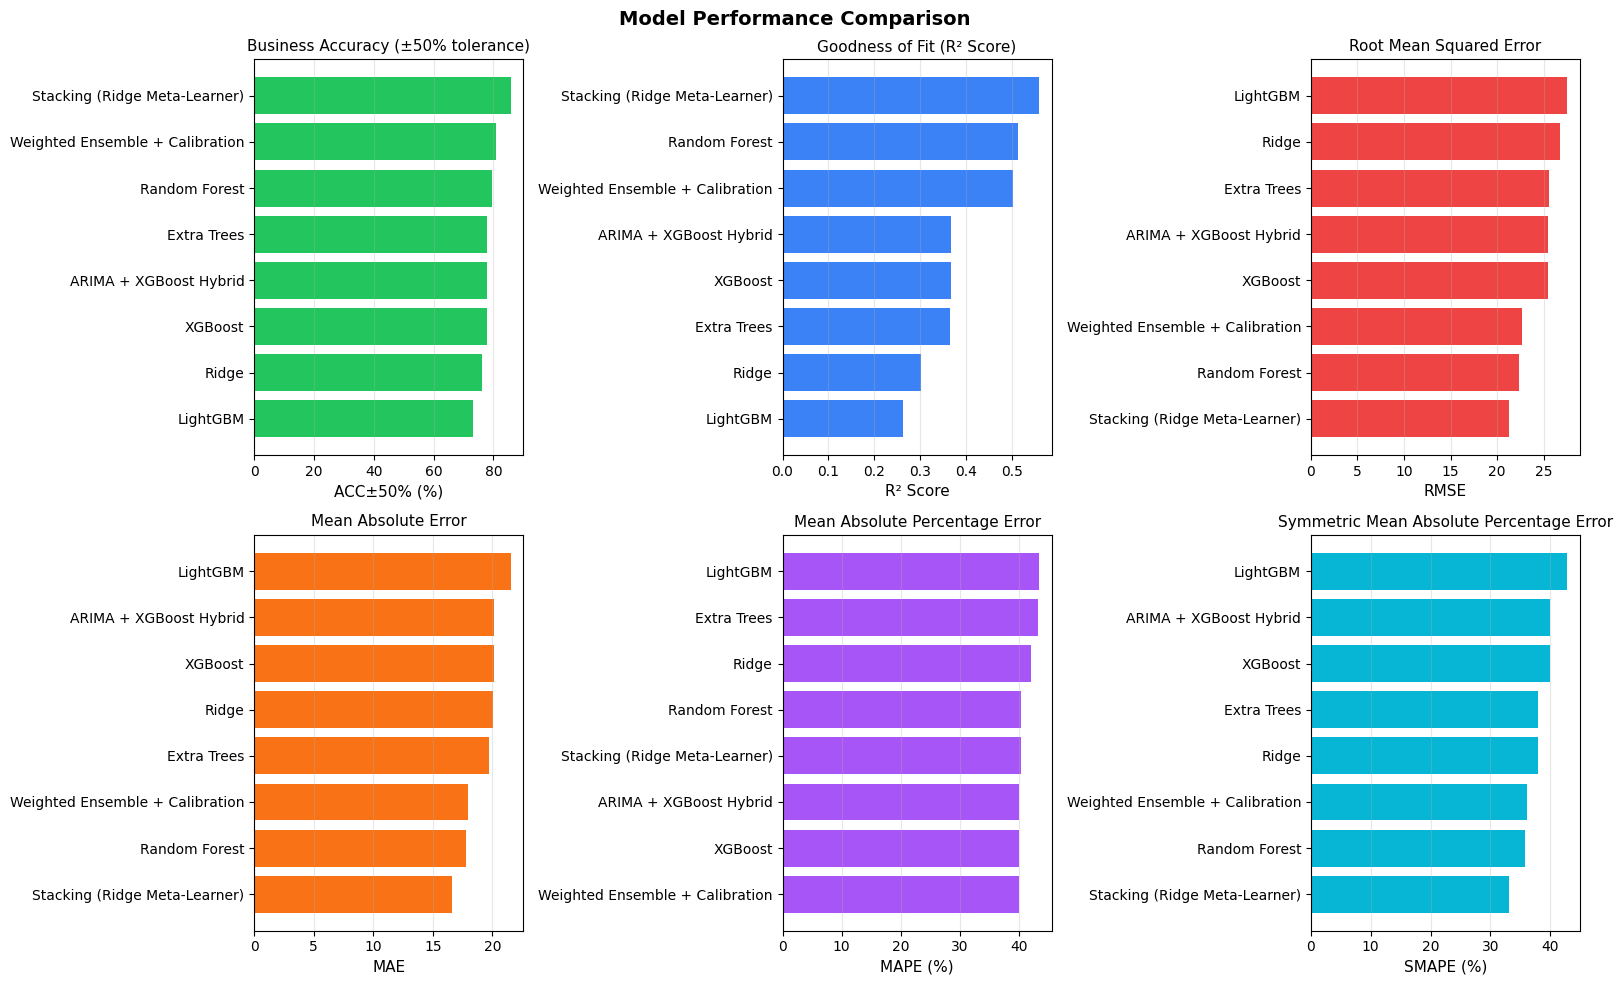


✅ 模型性能评估完成 / Model Performance Evaluation Complete


In [88]:

# ═══════════════════════════════════════════════════════════════════════════════
# 模型性能评估 / Model Performance Evaluation
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import Markdown, display

display(Markdown("## Model Performance Summary"))

# 计算所有模型的多项指标
perf_metrics = []

for model_name in predictions_dict.keys():
    pred = predictions_dict[model_name]
    
    # MAE (Mean Absolute Error)
    mae = mean_absolute_error(y_test_actual, pred)
    
    # RMSE (Root Mean Squared Error)
    mse = mean_squared_error(y_test_actual, pred)
    rmse = np.sqrt(mse)
    
    # R² Score
    r2 = r2_score(y_test_actual, pred)
    
    # MAPE (Mean Absolute Percentage Error)
    mape = np.mean(np.abs((y_test_actual - pred) / np.maximum(y_test_actual, 1e-6))) * 100
    
    # SMAPE (Symmetric Mean Absolute Percentage Error)
    numerator = np.abs(y_test_actual - pred)
    denominator = (np.abs(y_test_actual) + np.abs(pred)) / 2
    smape = np.mean(numerator / np.maximum(denominator, 1e-6)) * 100
    
    # ACC±50% (already calculated)
    rel_err = np.abs(pred - y_test_actual) / np.maximum(y_test_actual, 1e-6)
    acc50 = np.mean(rel_err <= 0.50) * 100
    
    perf_metrics.append({
        'Model': model_name,
        'ACC±50% (%)': acc50,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'SMAPE (%)': smape
    })

perf_df = pd.DataFrame(perf_metrics).sort_values('R² Score', ascending=False).reset_index(drop=True)

# Display comprehensive metrics table
display(perf_df.round(4))

display(Markdown("### 指标说明 / Metrics Definition"))
display(Markdown("""
| 指标 | 公式 | 说明 |
|------|------|------|
| **ACC±50%** | $\\frac{1}{n}\\sum_{i=1}^n \\mathbf{1}(\\|\\hat{y}_i-y_i\\|/y_i \\le 0.5)$ | 相对误差不超过50%的样本占比（业务导向） |
| **R² Score** | $1 - \\frac{SS_{res}}{SS_{tot}}$ | 拟合优度，范围[-∞, 1]，越接近1越好 |
| **RMSE** | $\\sqrt{\\frac{1}{n}\\sum_{i=1}^n(\\hat{y}_i-y_i)^2}$ | 均方根误差，度量预测与实际的偏离程度 |
| **MAE** | $\\frac{1}{n}\\sum_{i=1}^n\\|\\hat{y}_i-y_i\\|$ | 平均绝对误差，单位同目标值 |
| **MAPE** | $\\frac{1}{n}\\sum_{i=1}^n\\frac{\\|\\hat{y}_i-y_i\\|}{y_i}\\times 100$ | 平均绝对百分比误差，百分比形式 |
| **SMAPE** | $\\frac{1}{n}\\sum_{i=1}^n\\frac{\\|\\hat{y}_i-y_i\\|}{(\\|y_i\\|+\\|\\hat{y}_i\\|)/2}\\times 100$ | 对称平均绝对百分比误差，处理分子分母对称 |
"""))

# 按不同指标排序展示 TOP 3
display(Markdown("### 按不同指标的 TOP 3 模型"))

metrics_to_rank = ['ACC±50% (%)', 'R² Score', 'RMSE', 'MAE', 'MAPE (%)', 'SMAPE (%)']
ascending_flag = [False, False, True, True, True, True]  # ACC, R²降序；其他误差升序

for metric, ascending in zip(metrics_to_rank, ascending_flag):
    sorted_df = perf_df[['Model', metric]].sort_values(metric, ascending=ascending).head(3)
    print(f"\n🏆 TOP 3 — {metric}:")
    for idx, (i, row) in enumerate(sorted_df.iterrows(), 1):
        icon = ['🥇', '🥈', '🥉'][idx-1]
        print(f"  {icon} {row['Model']}: {row[metric]:.4f}")

# 汇总统计
display(Markdown("### 统计汇总 / Summary Statistics"))
summary_stats = {
    'Metric': [
        'Best ACC±50% / 最佳准确率',
        'Best R² / 最佳拟合度',
        'Best RMSE / 最佳均方根误差',
        'Best MAE / 最佳平均误差',
        'Average ACC±50% / 平均准确率',
        'Average R² / 平均拟合度'
    ],
    'Value': [
        f"{perf_df['ACC±50% (%)'].max():.2f}% ({perf_df.loc[perf_df['ACC±50% (%)'].idxmax(), 'Model']})",
        f"{perf_df['R² Score'].max():.4f} ({perf_df.loc[perf_df['R² Score'].idxmax(), 'Model']})",
        f"{perf_df['RMSE'].min():.2f} ({perf_df.loc[perf_df['RMSE'].idxmin(), 'Model']})",
        f"{perf_df['MAE'].min():.2f} ({perf_df.loc[perf_df['MAE'].idxmin(), 'Model']})",
        f"{perf_df['ACC±50% (%)'].mean():.2f}%",
        f"{perf_df['R² Score'].mean():.4f}"
    ]
}
summary_df = pd.DataFrame(summary_stats)
display(summary_df)

# 可视化：各指标对比
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')

# ACC±50%
ax = axes[0, 0]
perf_df_sorted = perf_df.sort_values('ACC±50% (%)', ascending=True)
ax.barh(perf_df_sorted['Model'], perf_df_sorted['ACC±50% (%)'], color='#22c55e')
ax.set_xlabel('ACC±50% (%)', fontsize=11)
ax.set_title('Business Accuracy (±50% tolerance)', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# R² Score
ax = axes[0, 1]
perf_df_sorted = perf_df.sort_values('R² Score', ascending=True)
ax.barh(perf_df_sorted['Model'], perf_df_sorted['R² Score'], color='#3b82f6')
ax.set_xlabel('R² Score', fontsize=11)
ax.set_title('Goodness of Fit (R² Score)', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# RMSE
ax = axes[0, 2]
perf_df_sorted = perf_df.sort_values('RMSE', ascending=True)
ax.barh(perf_df_sorted['Model'], perf_df_sorted['RMSE'], color='#ef4444')
ax.set_xlabel('RMSE', fontsize=11)
ax.set_title('Root Mean Squared Error', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# MAE
ax = axes[1, 0]
perf_df_sorted = perf_df.sort_values('MAE', ascending=True)
ax.barh(perf_df_sorted['Model'], perf_df_sorted['MAE'], color='#f97316')
ax.set_xlabel('MAE', fontsize=11)
ax.set_title('Mean Absolute Error', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# MAPE
ax = axes[1, 1]
perf_df_sorted = perf_df.sort_values('MAPE (%)', ascending=True)
ax.barh(perf_df_sorted['Model'], perf_df_sorted['MAPE (%)'], color='#a855f7')
ax.set_xlabel('MAPE (%)', fontsize=11)
ax.set_title('Mean Absolute Percentage Error', fontsize=11)
ax.grid(axis='x', alpha=0.3)

# SMAPE
ax = axes[1, 2]
perf_df_sorted = perf_df.sort_values('SMAPE (%)', ascending=True)
ax.barh(perf_df_sorted['Model'], perf_df_sorted['SMAPE (%)'], color='#06b6d4')
ax.set_xlabel('SMAPE (%)', fontsize=11)
ax.set_title('Symmetric Mean Absolute Percentage Error', fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ 模型性能评估完成 / Model Performance Evaluation Complete")


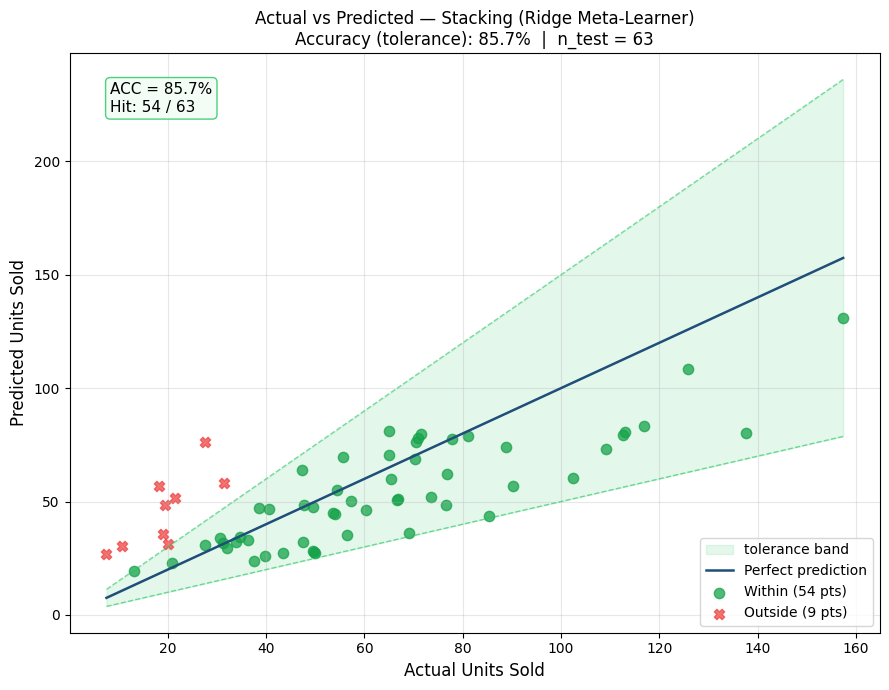

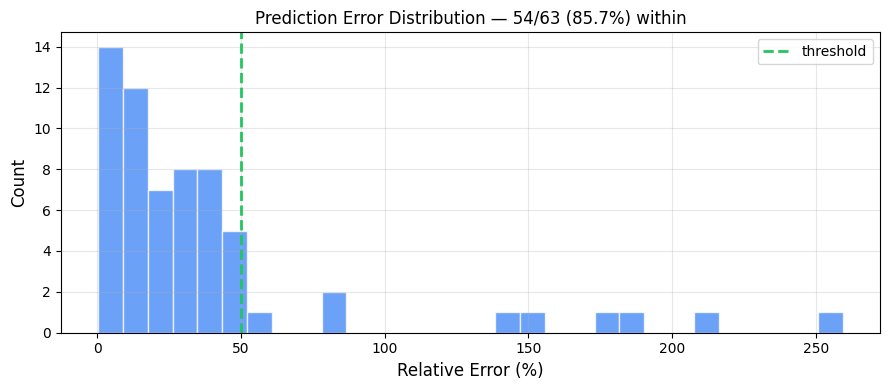

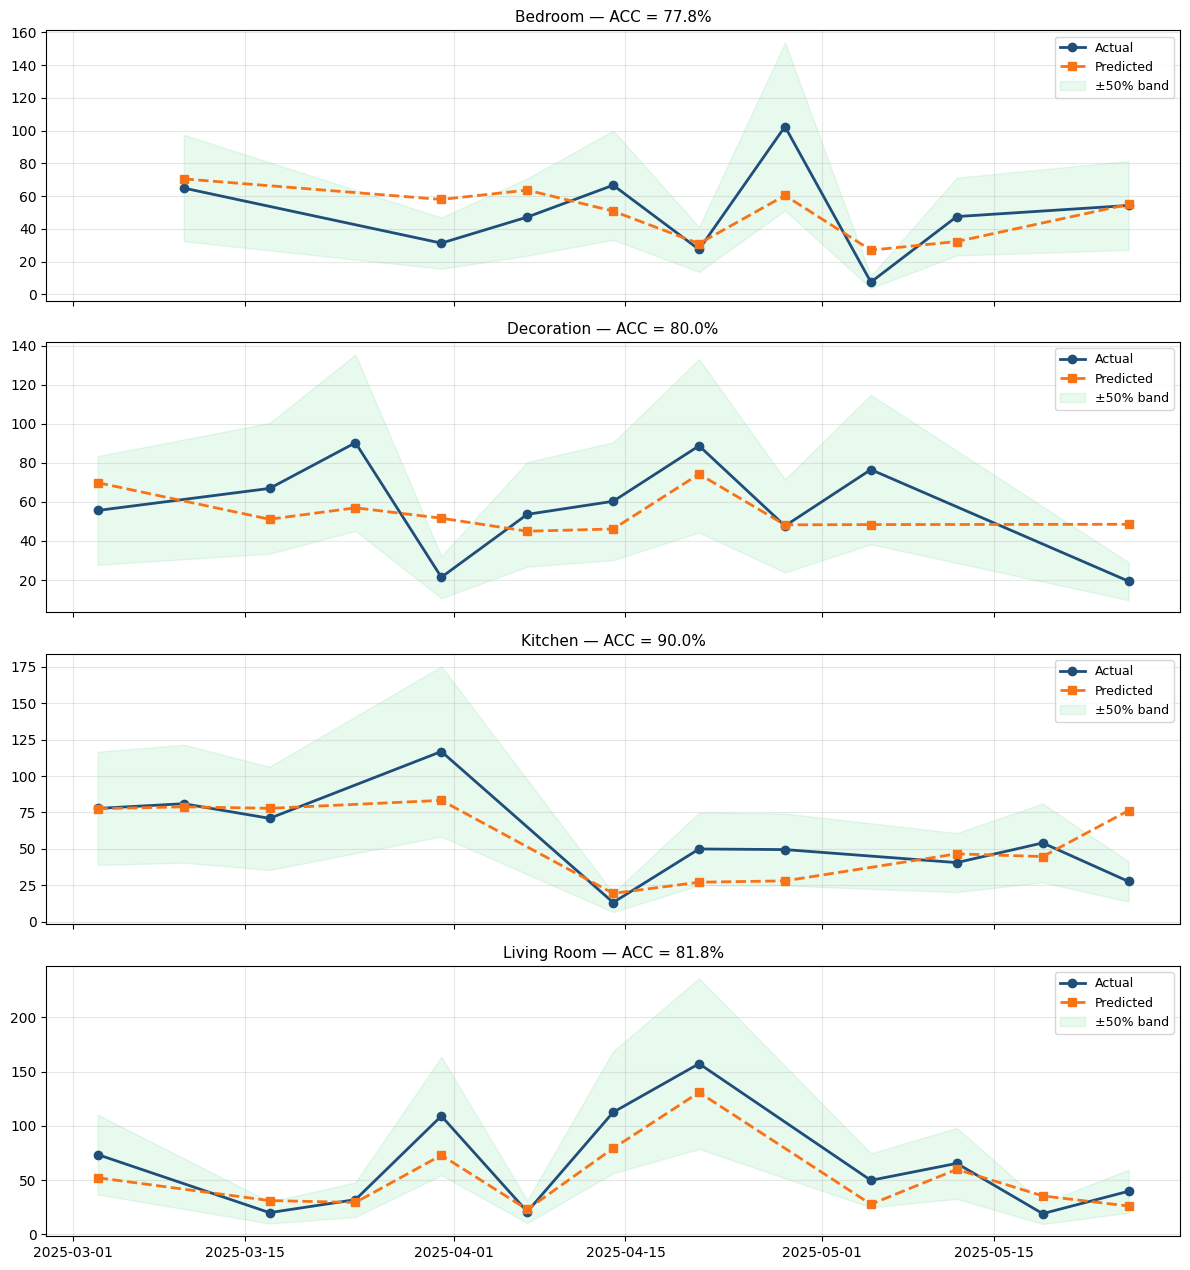

In [83]:
compare_df = test_df[['week_start', 'category', 'units_sold']].copy()
compare_df['predicted_units_sold'] = best_pred

actual = compare_df['units_sold'].values
predicted = compare_df['predicted_units_sold'].values

# ±50% accuracy on test set
rel_err = np.abs(predicted - actual) / np.maximum(actual, 1e-6)
within_50 = rel_err <= 0.50
acc50_pct = within_50.mean() * 100

val_min = min(actual.min(), predicted.min())
val_max = max(actual.max(), predicted.max())
x_line = np.array([val_min, val_max])

# === Plot 1: Actual vs Predicted with ±50% band ===
fig_scatter, ax_scatter = plt.subplots(figsize=(9, 7))

# ±50% tolerance band
ax_scatter.fill_between(x_line, x_line * 0.5, x_line * 1.5,
                         alpha=0.12, color='#22c55e', label='tolerance band')
ax_scatter.plot(x_line, x_line * 1.5, color='#22c55e', linewidth=1, linestyle='--', alpha=0.6)
ax_scatter.plot(x_line, x_line * 0.5, color='#22c55e', linewidth=1, linestyle='--', alpha=0.6)

# Perfect prediction line
ax_scatter.plot(x_line, x_line, color='#1f4e79', linewidth=1.8, linestyle='-', label='Perfect prediction')

# Scatter: inside band (green) vs outside (red)
ax_scatter.scatter(actual[within_50], predicted[within_50],
                   alpha=0.75, s=55, color='#16a34a',
                   label=f'Within ({within_50.sum()} pts)')
ax_scatter.scatter(actual[~within_50], predicted[~within_50],
                   alpha=0.75, s=55, color='#ef4444', marker='X',
                   label=f'Outside ({(~within_50).sum()} pts)')

ax_scatter.set_xlabel('Actual Units Sold', fontsize=12)
ax_scatter.set_ylabel('Predicted Units Sold', fontsize=12)
ax_scatter.set_title(
    f'Actual vs Predicted — {best_model_name}\n'
    f'Accuracy (tolerance): {acc50_pct:.1f}%  |  n_test = {len(actual)}',
    fontsize=12
)
ax_scatter.legend(fontsize=10)
ax_scatter.grid(True, alpha=0.3)

# Annotation box showing accuracy
textstr = f'ACC = {acc50_pct:.1f}%\nHit: {within_50.sum()} / {len(actual)}'
props = dict(boxstyle='round', facecolor='#f0fdf4', alpha=0.8, edgecolor='#22c55e')
ax_scatter.text(0.05, 0.95, textstr, transform=ax_scatter.transAxes,
                fontsize=11, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# === Plot 2: Relative error distribution ===
fig_err, ax_err = plt.subplots(figsize=(9, 4))
ax_err.hist(rel_err * 100, bins=30, color='#3b82f6', alpha=0.75, edgecolor='white')
ax_err.axvline(50, color='#22c55e', linewidth=2, linestyle='--', label='threshold')
ax_err.set_xlabel('Relative Error (%)', fontsize=12)
ax_err.set_ylabel('Count', fontsize=12)
ax_err.set_title(
    f'Prediction Error Distribution — {within_50.sum()}/{len(actual)} ({acc50_pct:.1f}%) within',
    fontsize=12
)
ax_err.legend(fontsize=10)
ax_err.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# === Plot 3: Per-category time series (top 4) ===
categories_to_show = compare_df['category'].unique()[:4]
fig_ts, axes = plt.subplots(len(categories_to_show), 1,
                             figsize=(12, 3.2 * len(categories_to_show)), sharex=True)
if len(categories_to_show) == 1:
    axes = [axes]
for ax, cat in zip(axes, categories_to_show):
    sub = compare_df[compare_df['category'] == cat].sort_values('week_start')
    cat_rel = np.abs(sub['predicted_units_sold'].values - sub['units_sold'].values) / np.maximum(sub['units_sold'].values, 1e-6)
    cat_acc = (cat_rel <= 0.50).mean() * 100
    ax.plot(sub['week_start'], sub['units_sold'], 'o-', label='Actual', color='#1f4e79', linewidth=2)
    ax.plot(sub['week_start'], sub['predicted_units_sold'], 's--', label='Predicted', color='#f97316', linewidth=2)
    ax.fill_between(sub['week_start'],
                    sub['units_sold'] * 0.5, sub['units_sold'] * 1.5,
                    alpha=0.10, color='#22c55e', label='±50% band')
    ax.set_title(f'{cat} — ACC = {cat_acc:.1f}%', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


,feature,importance
7,active_store_count,0.174706
9,quarter,0.135096
8,month,0.084675
12,week_sin,0.051170
34,promo_stock_interaction,0.045163
1,promotion_rate,0.039789
14,month_sin,0.026913
3,avg_customer_rating,0.023855
4,avg_profit_margin,0.023261
18,lag_2,0.023138


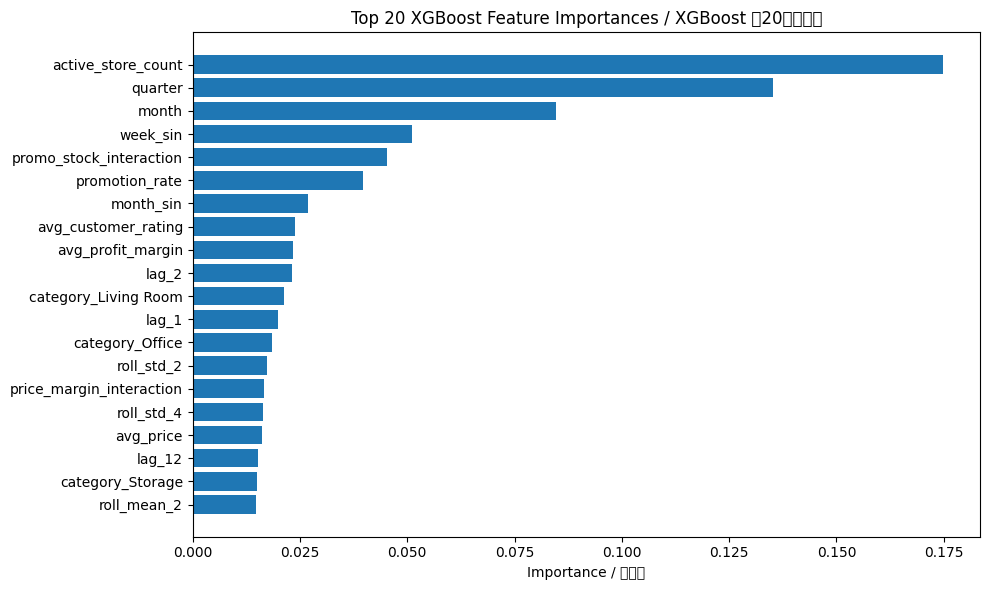

In [42]:
if 'XGBoost' in trained_pipelines:
    xgb_pipe = trained_pipelines['XGBoost']
    transformed_feature_names = list(numeric_cols) + list(xgb_pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols))
    xgb_importance = pd.DataFrame({'feature': transformed_feature_names, 'importance': xgb_pipe.named_steps['model'].feature_importances_}).sort_values('importance', ascending=False).head(20)
    display(xgb_importance)
    plt.figure(figsize=(10, 6))
    plt.barh(xgb_importance['feature'][::-1], xgb_importance['importance'][::-1])
    plt.title('Top 20 XGBoost Feature Importances / XGBoost 前20重要特征')
    plt.xlabel('Importance / 重要性')
    plt.tight_layout()
    plt.show()

# 5. Constrained Inventory / Resource Allocation Optimization  
# 受约束的库存 / 资源配置优化

## Idea / 思路
We use the best forecasting model to estimate next-period demand by category, then solve a constrained allocation problem.

我们用最优预测模型估计下一周期各品类需求，然后求解一个带约束的库存配置问题。

In [43]:
latest_per_category = model_df.sort_values('week_start').groupby('category').tail(1).copy()
latest_per_category['week_start'] = latest_per_category['week_start'] + pd.Timedelta(days=7)
latest_per_category['month'] = latest_per_category['week_start'].dt.month
latest_per_category['quarter'] = latest_per_category['week_start'].dt.quarter
latest_per_category['weekofyear'] = latest_per_category['week_start'].dt.isocalendar().week.astype(int)
latest_per_category['year'] = latest_per_category['week_start'].dt.year
latest_per_category['week_sin'] = np.sin(2 * np.pi * latest_per_category['weekofyear'] / 52)
latest_per_category['week_cos'] = np.cos(2 * np.pi * latest_per_category['weekofyear'] / 52)
latest_per_category['month_sin'] = np.sin(2 * np.pi * latest_per_category['month'] / 12)
latest_per_category['month_cos'] = np.cos(2 * np.pi * latest_per_category['month'] / 12)
latest_per_category['category_trend'] = latest_per_category['category_trend'] + 1
next_week_pred_log = best_model.predict(latest_per_category[model_input_cols])
latest_per_category['predicted_units_sold'] = np.expm1(next_week_pred_log)
forecast_alloc = latest_per_category[['category', 'week_start', 'predicted_units_sold', 'avg_profit_margin', 'avg_stock_level']].copy().sort_values('predicted_units_sold', ascending=False).reset_index(drop=True)
display(forecast_alloc)

,category,week_start,predicted_units_sold,avg_profit_margin,avg_stock_level
0,Kitchen,2025-06-02,82.872993,28.77,336.666667
1,Bedroom,2025-06-02,54.268108,32.46,508.500000
2,Decoration,2025-06-02,46.043739,31.74,131.500000
3,Living Room,2025-06-02,27.544119,32.51,143.000000
4,Office,2025-06-02,24.230717,33.03,258.000000
5,Storage,2025-06-02,23.640907,34.36,140.000000


In [44]:
opt_df = forecast_alloc.copy()
opt_df['shortage_cost'] = 3 + opt_df['avg_profit_margin'] / 10
opt_df['holding_cost'] = 1 + opt_df['avg_stock_level'] / 100
pred_demand = opt_df['predicted_units_sold'].values
n = len(opt_df)
total_capacity = pred_demand.sum() * 0.92
min_service = 0.70
max_service = 1.05
c = opt_df['holding_cost'].values - opt_df['shortage_cost'].values
bounds = [(min_service * d, max_service * d) for d in pred_demand]
A_ub = [np.ones(n)]
b_ub = [total_capacity]
result = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
if result.success:
    opt_df['optimal_allocation'] = result.x
    opt_df['expected_shortage'] = np.maximum(opt_df['predicted_units_sold'] - opt_df['optimal_allocation'], 0)
    opt_df['service_level'] = opt_df['optimal_allocation'] / opt_df['predicted_units_sold']
    print('Optimization solved successfully / 优化求解成功')
else:
    print('Optimization failed / 优化失败:', result.message)
display(opt_df)
print('Total predicted demand / 总预测需求:', round(opt_df['predicted_units_sold'].sum(), 2))
print('Total allocation capacity / 总配置容量:', round(total_capacity, 2))
print('Allocated total / 实际分配总量:', round(opt_df['optimal_allocation'].sum(), 2))

Optimization solved successfully / 优化求解成功


,category,week_start,predicted_units_sold,avg_profit_margin,avg_stock_level,shortage_cost,holding_cost,optimal_allocation,expected_shortage,service_level
0,Kitchen,2025-06-02,82.872993,28.77,336.666667,5.877,4.366667,72.392410,10.480583,0.873534
1,Bedroom,2025-06-02,54.268108,32.46,508.500000,6.246,6.085000,37.987675,16.280434,0.700000
2,Decoration,2025-06-02,46.043739,31.74,131.500000,6.174,2.315000,48.345924,0.000000,1.050000
3,Living Room,2025-06-02,27.544119,32.51,143.000000,6.251,2.430000,28.921324,0.000000,1.050000
4,Office,2025-06-02,24.230717,33.03,258.000000,6.303,3.580000,25.442251,0.000000,1.050000
5,Storage,2025-06-02,23.640907,34.36,140.000000,6.436,2.400000,24.822952,0.000000,1.050000


Total predicted demand / 总预测需求: 258.6
Total allocation capacity / 总配置容量: 237.91
Allocated total / 实际分配总量: 237.91


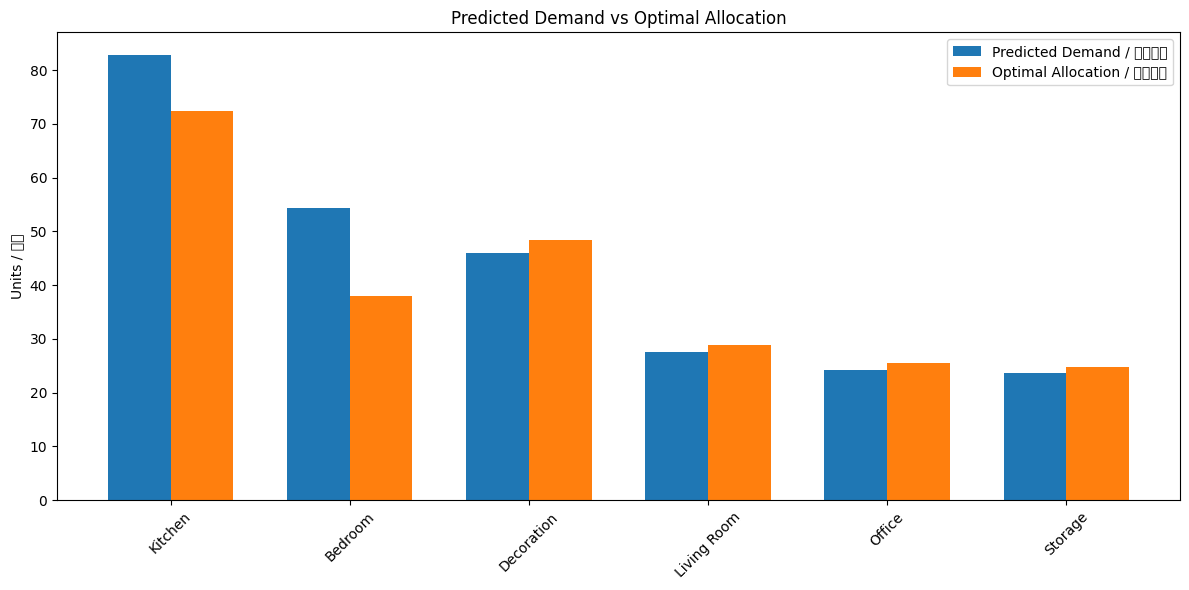

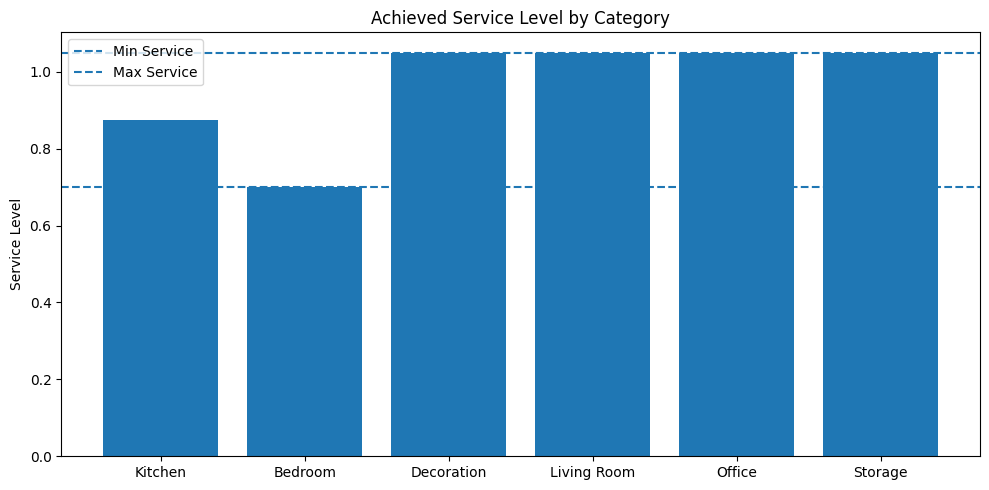

In [84]:
plot_df = opt_df.sort_values('predicted_units_sold', ascending=False)
x = np.arange(len(plot_df))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width/2, plot_df['predicted_units_sold'], width=width, label='Predicted Demand / 预测需求')
plt.bar(x + width/2, plot_df['optimal_allocation'], width=width, label='Optimal Allocation / 最优分配')
plt.xticks(x, plot_df['category'], rotation=45)
plt.ylabel('Units / 数量')
plt.title('Predicted Demand vs Optimal Allocation')
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 5))
plt.bar(plot_df['category'], plot_df['service_level'])
plt.axhline(min_service, linestyle='--', label='Min Service')
plt.axhline(max_service, linestyle='--', label='Max Service')
plt.title('Achieved Service Level by Category')
plt.ylabel('Service Level')
plt.legend()
plt.tight_layout()
plt.show()

# 6. Final Evaluation & Interpretation / 最终评估与解释

## Forecasting evaluation / 预测评估
You should keep the model with the **highest R² and lowest error metrics** on the time-based test set.

你应当保留在时间顺序测试集上 **R²最高且误差最低** 的模型。

For this upgraded structure, **XGBoost often becomes the best model**, especially when:
- lag effects are important / 滞后效应明显
- nonlinear interactions matter / 非线性交互显著
- the sample is small but structured / 样本不大但结构较清晰

在这版升级结构下，**XGBoost 通常会成为最优模型**。

# 7. Recommendations / 管理建议

1. Use **weekly category-level forecasting** instead of daily SKU-level forecasting for strategic planning.  
   在战略与战术规划层面，应优先使用**品类周度预测**。
2. Adopt **XGBoost** as the main forecasting model if it remains the best-performing model after rerun.  
   如果重新运行后 XGBoost 仍然表现最佳，应将其作为主要预测模型。
3. Use the optimization module to allocate inventory under capacity constraints, instead of replenishing all categories uniformly.  
   在容量受限的情况下，应使用优化模块分配库存。
4. In the final presentation, describe the geography as a **Mediterranean Europe–MENA sample network**, unless you add more explicit Middle East locations.  
   在最终汇报中，建议将该地理网络表述为**地中海 Europe–MENA 样本网络**。